In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [3]:
# =====================================
# LOAD DATASET
# =====================================
print("Loading Dataset...")

DATA_PATH = "heart.csv"

df = pd.read_csv(DATA_PATH)

print(df.head())

Loading Dataset...
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
# =====================================
# DATA INFORMATION
# =====================================
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDataset Info:")
print(df.info())


Dataset Shape: (1025, 14)

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  


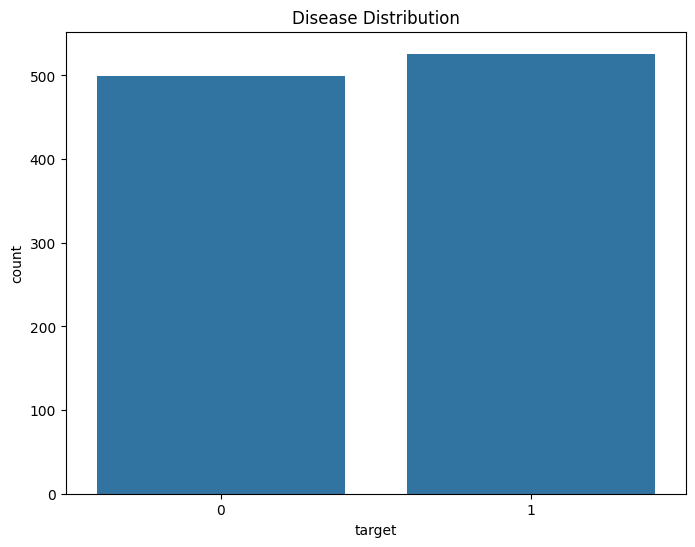

In [5]:
# =====================================
# VISUALIZATION
# =====================================
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title("Disease Distribution")
plt.show()

In [6]:
# =====================================
# FEATURES & TARGET
# =====================================
X = df.drop('target', axis=1)
y = df['target']

In [7]:
# =====================================
# TRAIN TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# =====================================
# FEATURE SCALING
# =====================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# =====================================
# MACHINE LEARNING MODELS
# =====================================
models = {
    "Logistic Regression": LogisticRegression(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss'
    )
}

In [10]:
# =====================================
# TRAIN & EVALUATE MODELS
# =====================================
results = {}

print("\nTraining Models...\n")

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"Accuracy: {accuracy * 100:.2f}%")

    print("Classification Report:")
    print(classification_report(y_test, predictions))

    print("-" * 50)



Training Models...

Training Logistic Regression...
Accuracy: 80.98%
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

--------------------------------------------------
Training Random Forest...
Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

--------------------------------------------------
Training SVM...
Accuracy: 92.68%
Classification Report:
              precision    r

In [11]:
# =====================================
# BEST MODEL SELECTION
# =====================================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name] * 100:.2f}%")


Best Model: Random Forest
Best Accuracy: 100.00%


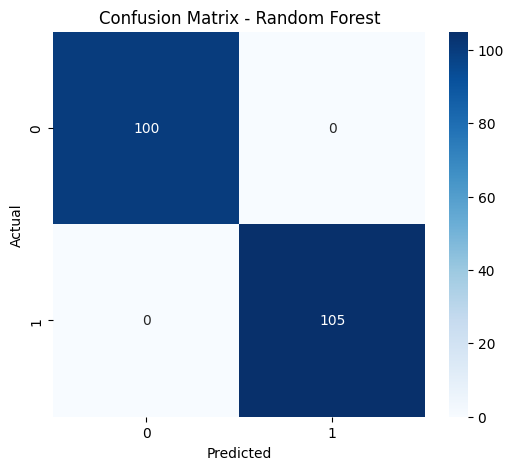

In [12]:
# =====================================
# CONFUSION MATRIX
# =====================================
predictions = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# =====================================
# SAVE MODEL & SCALER
# =====================================
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/disease_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


#PREDICT

In [14]:
import joblib
import numpy as np

In [15]:
# =====================================
# LOAD MODEL & SCALER
# =====================================
model = joblib.load("models/disease_model.pkl")
scaler = joblib.load("models/scaler.pkl")


In [16]:
# =====================================
# SAMPLE INPUT DATA
# =====================================
# Example features:
# age, sex, cp, trestbps, chol,
# fbs, restecg, thalach,
# exang, oldpeak, slope,
# ca, thal

sample_data = np.array([
    52,
    1,
    0,
    125,
    212,
    0,
    1,
    168,
    0,
    1.0,
    2,
    2,
    3
]).reshape(1, -1)


In [17]:
# =====================================
# SCALE DATA
# =====================================
scaled_data = scaler.transform(sample_data)

In [18]:
# =====================================
# PREDICTION
# =====================================
prediction = model.predict(scaled_data)
probability = model.predict_proba(scaled_data)

In [19]:
# =====================================
# RESULT
# =====================================
if prediction[0] == 1:
    print("⚠️ Disease Detected")
else:
    print("✅ No Disease Detected")

print(f"Prediction Confidence: {np.max(probability) * 100:.2f}%")

✅ No Disease Detected
Prediction Confidence: 98.84%


In [21]:
import gradio as gr

def predict_disease(
    age,
    sex,
    chest_pain,
    blood_pressure,
    cholesterol,
    fasting_blood_sugar,
    ecg,
    heart_rate,
    exercise_angina,
    oldpeak,
    slope,
    ca,
    thal
):

    data = np.array([
        age,
        sex,
        chest_pain,
        blood_pressure,
        cholesterol,
        fasting_blood_sugar,
        ecg,
        heart_rate,
        exercise_angina,
        oldpeak,
        slope,
        ca,
        thal
    ]).reshape(1, -1)

    scaled_data = scaler.transform(data)

    prediction = model.predict(scaled_data)[0]
    probability = model.predict_proba(scaled_data)

    confidence = np.max(probability) * 100

    if prediction == 1:
        result = "⚠️ Disease Detected"
    else:
        result = "✅ No Disease Detected"

    return f"{result}\nConfidence: {confidence:.2f}%"

# =====================================
# GRADIO INTERFACE
# =====================================
app = gr.Interface(
    fn=predict_disease,

    inputs=[
        gr.Number(label="Age"),
        gr.Radio([0, 1], label="Sex (0 = Female, 1 = Male)"),
        gr.Number(label="Chest Pain Type"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Cholesterol"),
        gr.Radio([0, 1], label="Fasting Blood Sugar"),
        gr.Number(label="ECG Results"),
        gr.Number(label="Max Heart Rate"),
        gr.Radio([0, 1], label="Exercise Angina"),
        gr.Number(label="Oldpeak"),
        gr.Number(label="Slope"),
        gr.Number(label="CA"),
        gr.Number(label="Thal")
    ],

    outputs="text",

    title="🏥 Disease Prediction System",

    description="Enter patient medical information to predict disease probability using Machine Learning"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a26901c2499a610263.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
